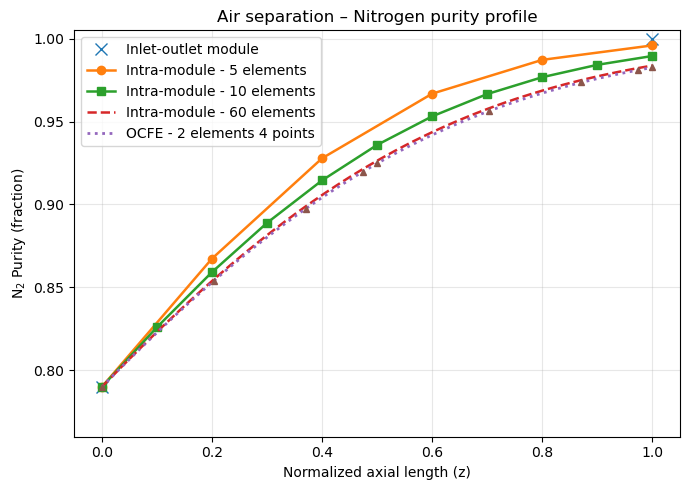

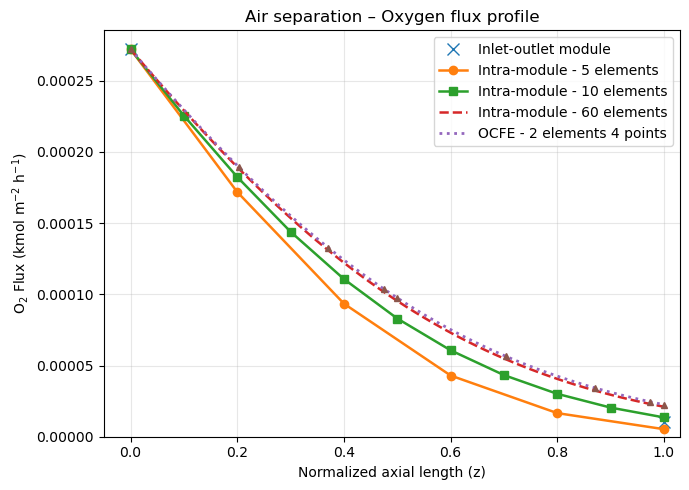


Final values:
  FE-5 final N2 purity:         0.995919
  FE-10 final N2 purity:        0.989545
  FE-60 final N2 purity:        0.983767
  OCFE final N2 purity:         0.982623


In [3]:
# OCFE Modeling for Air Separation Case Study
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root
%matplotlib inline

# The variable definition
#   F_i^R : retentate-side component flowrate of species i
#   F_i^S : permeate-side component flowrate of species i
#   x_i^R : retentate-side mole fraction of species i
#   x_i^S : permeate-side mole fraction of species i
#   p_i^R = x_i^R * P^R : retentate-side partial pressure of species i
#   p_i^S = x_i^S * P^S : permeate-side partial pressure of species i
#   J_i   = Pi_i * (p_i^R - p_i^S) : local molar flux of species i

# The OCFE residual:
#   (1 / h_l) * sum_k D_{j,k} * F_i^R(s_{l,k}) + A_m * J_i(s_{l,j}) = 0
#   (1 / h_l) * sum_k D_{j,k} * F_i^S(s_{l,k}) - A_m * J_i(s_{l,j}) = 0


def GPU_to_kmol_m2_h_bar(GPU):
    """
    Convert permeance from GPU to kmol m^-2 h^-1 bar^-1.

        1 GPU = 3.348e-10 mol m^-2 s^-1 Pa^-1

    Convertion:
      mol to kmol     by dividing by 1000
      s   to h        by multiplying by 3600
      Pa  to bar      by multiplying by 1.0e5
        Permeance in kmol m^-2 h^-1 bar^-1.
    """
    # Multiply the given GPU value by the full unit-conversion factor.
    return GPU * 3.348e-10 * 1.0e5 * 3600.0 / 1000.0


def lagrange_basis_weights(s_nodes, s_eval):
    """
    Compute the Lagrange interpolation weights W_j(s_eval),
    where a variable inside one finite element is approximated by
    a polynomial passing through values at the collocation nodes.

    Parameters:
    s_nodes : array-like
        The interpolation/collocation nodes inside one finite element.
    s_eval : float
        The local coordinate s at which we want to evaluate the interpolating polynomial.

    Returns:
    W : numpy.ndarray
        Array of weights W_j(s_eval), one for each node j.
    """
    # Convert the node list to a NumPy array of floating-point values.
    s_nodes = np.asarray(s_nodes, dtype=float)

    # Start with an array of ones because each Lagrange basis polynomial
    # is a product of several factors multiplied together.
    W = np.ones(len(s_nodes), dtype=float)

    # Loop over each basis polynomial index j.
    for j in range(len(s_nodes)):
        # For basis polynomial j, multiply over all other node indices k != j.
        for k in range(len(s_nodes)):
            # Skip the term where k == j because that factor is not included in the product.
            if k != j:
                # Multiply by the standard Lagrange factor:
                # (s_eval - s_k) / (s_j - s_k)
                W[j] *= (s_eval - s_nodes[k]) / (s_nodes[j] - s_nodes[k])

    # Return the full vector of interpolation weights.
    return W

def lagrange_derivative_matrix(s_nodes):
    """
    Construct the derivative matrix D for Lagrange collocation.

    We need the derivative matrix to turn differential equations into algebraic equations that the solver can solve.
    Suppose one element has 3 nodes: s = [0, 0.5, 1], flow values = [10, 7, 4], devivative matrix, D = [-3 4 -1, -1 0 1, 1 -4 3],
    then the derivative at the middle node is dF/ds at 0.5 is -1(10)+0(7)+1(4)=-6.

    In OCFE, we start with a differential equation (dF/dz) but a solver cannot directly handle the dF/dz. Derivative matrix converts
    dF/dz into algebric equations which solver can solve easily. dF/dz = summation (Dj,k * Fk) = flux term
    Parameters:
    s_nodes : array-like
        Local collocation/interpolation nodes inside one finite element.

    Returns:
    D : numpy.ndarray
        The derivative matrix D_{i,j}.
    """
    # Convert the node list into a NumPy float array for safe numerical use.
    s_nodes = np.asarray(s_nodes, dtype=float)

    # Store the number of nodes.
    n = len(s_nodes)

    # Initialize the weights array with ones.
    # These weights help construct the derivative matrix efficiently and accurately.
    bary = np.ones(n, dtype=float)
    # Loop over node index j to compute each weight.
    for j in range(n):
        # For each node j, loop over all other nodes k.
        for k in range(n):
            # Exclude the self-term because the product is only over k != j.
            if k != j:
                # Divide bary[j] by (s_j - s_k), building the product-form denominator.
                bary[j] /= (s_nodes[j] - s_nodes[k])

    # Initialize the derivative matrix D as an n by n zero matrix.
    D = np.zeros((n, n), dtype=float)

    # Loop over row index i, which corresponds to the point where the derivative is evaluated.
    for i in range(n):
        # Loop over column index j, which corresponds to the basis function being differentiated.
        for j in range(n):
            # Off-diagonal entries follow the differentiation formula.
            if i != j:
                # Compute D[i,j] from weights and node spacing.
                D[i, j] = bary[j] / (bary[i] * (s_nodes[i] - s_nodes[j]))
        # Set the diagonal entry so that each row sums to zero.
        # This is the standard and numerically stable way to complete D.
        D[i, i] = -np.sum(D[i, :])

    # Return the completed derivative matrix.
    return D


def composition(F):
    """
    Compute species mole fractions and total flowrate from component flowrates.
    """
    # Sum the component flowrates to obtain the total flowrate.
    F_total = sum(F.values())

    # If the total flow is zero or negative, avoid division by zero.
    # In that case, return equal mole fractions as a safe fallback plus total flow = 0.
    if F_total <= 0.0:
        # Count how many species appear in the dictionary.
        n = len(F)

        # Return equal fractions for all species and zero total flow.
        return {i: 1.0 / n for i in F}, 0.0

    # Otherwise, return the normal mole fraction definition x_i = F_i / F_total.
    return {i: F[i] / F_total for i in F}, F_total


def local_flux(F_R, F_S, P_R, P_S, Pi):
    """
    Compute the local gas-separation fluxes.

    For gas separation:
        J_i = Pi_i * (p_i^R - p_i^S)

    with:
        p_i^R = x_i^R * P^R
        p_i^S = x_i^S * P^S

    Parameters:
    F_R : dict
        Retentate-side component flowrates.
    F_S : dict
        Permeate-side component flowrates.
    P_R : float
        Retentate-side pressure in bar.
    P_S : float
        Permeate-side pressure in bar.
    Pi : dict
        Species permeances.

    Returns:
    J : dict
        Local species fluxes.
    x_R : dict
        Retentate-side mole fractions.
    x_S : dict
        Permeate-side mole fractions.
    p_R : dict
        Retentate-side partial pressures.
    p_S : dict
        Permeate-side partial pressures.
    """
    # Compute retentate-side composition and retentate-side total flowrate.
    x_R, F_R_total = composition(F_R)

    # Compute permeate-side composition and permeate-side total flowrate.
    x_S, F_S_total = composition(F_S)

    # Compute retentate-side partial pressures p_i^R = x_i^R * P^R.
    p_R = {i: x_R[i] * P_R for i in F_R}

    # If permeate-side total flow is extremely small, set permeate-side partial pressures to zero.
    if F_S_total <= 1.0e-14:
        # Set all permeate-side partial pressures to zero.
        p_S = {i: 0.0 for i in F_S}
    else:
        # Otherwise compute p_i^S = x_i^S * P^S normally.
        p_S = {i: x_S[i] * P_S for i in F_S}

    # Compute the local species fluxes using the gas-separation flux law.
    # The max(..., 0.0) prevents negative flux in case a local driving force becomes negative numerically.
    #J = {i: max(Pi[i] * (p_R[i] - p_S[i]), 0.0) for i in F_R} # We can use this expression
    J = {i:(Pi[i] * (p_R[i] - p_S[i])) for i in F_R} # We can also use this expression. If zero flux happens, it will be reflected in figure plotting.
    # Return the full set of local quantities.
    return J, x_R, x_S, p_R, p_S


def make_air_separation_parameters(permeance_mode="effective"):
    """
    Build and return the base parameter set.

    Modes:
    permeance_mode = "effective"
        Uses effective permeances chosen.

    permeance_mode = "gpu"
        Uses literal conversion of 1600 GPU for O2 and 160 GPU for N2.

    Returns:
    params : dict
        Dictionary containing all required parameters.
    """
    # Define the species list used in this air-separation problem.
    species = ["N2", "O2"]

    # Define the inlet retentate-side feed flowrates.
    # Total feed = 2.3 kmol/h and composition is 79% N2 and 21% O2.
    F_RI = {"N2": 2.3 * 0.79, "O2": 2.3 * 0.21}

    # Define the inlet permeate-side flowrates.
    # No sweep gas.
    F_SI = {"N2": 0.0, "O2": 0.0}

    # Set the retentate-side pressure in bar.
    P_R = 10.0

    # Set the permeate-side pressure in bar.
    P_S = 0.0

    # Set the total membrane length.
    L_m = 20.0

    # Choose either permeance or gpu mode.
    if permeance_mode == "effective":
        # Use effective permeance values in kmol m^-2 h^-1 bar^-1.
        Pi = {"O2": 0.00012954, "N2": 0.000012954}

        # Total membrane area.
        A_m = 4000.0

    elif permeance_mode == "gpu":
        # Use literal GPU-based permeance conversion for O2 and N2.
        Pi = {
            "O2": GPU_to_kmol_m2_h_bar(1600.0),
            "N2": GPU_to_kmol_m2_h_bar(160.0),
        }

        # membrane area.
        A_m = 4000.0

        # Permeate pressure
        P_S = 1.0

    else:
        raise ValueError

    # Return all parameters in one dictionary so downstream functions can use them cleanly.
    return {
        "species": species,
        "F_RI": F_RI,
        "F_SI": F_SI,
        "P_R": P_R,
        "P_S": P_S,
        "Pi": Pi,
        "A_m": A_m,
        "L_m": L_m,
    }


def simulate_inlet_outlet(params):
    """
    Simulate the inlet-outlet model.

    This model does not resolve spatial variation.
    It uses inlet conditions to compute one constant driving force
    for the entire membrane module.

    Balances:
        F_i^RI - F_i^RO - J_i * A_m = 0
        F_i^SI - F_i^SO + J_i * A_m = 0
    """
    # Read the species list from the parameter dictionary.
    species = params["species"]

    # Read the retentate-side inlet flowrates.
    F_RI = params["F_RI"]

    # Read the permeate-side inlet flowrates.
    F_SI = params["F_SI"]

    # Read the retentate-side pressure.
    P_R = params["P_R"]

    # Read the permeate-side pressure.
    P_S = params["P_S"]

    # Read the permeance dictionary.
    Pi = params["Pi"]

    # Read the total membrane area.
    A_m = params["A_m"]

    # Compute the lumped-model inlet flux from inlet conditions.
    J_in, x_RI, _, _, _ = local_flux(F_RI, F_SI, P_R, P_S, Pi)

    # Compute outlet retentate flowrates using the inlet-outlet balance.
    F_RO = {i: max(F_RI[i] - J_in[i] * A_m, 0.0) for i in species}

    # Compute outlet permeate flowrates using the inlet-outlet balance.
    F_SO = {i: F_SI[i] + J_in[i] * A_m for i in species}

    # Compute outlet retentate composition.
    x_RO, _ = composition(F_RO)

    # Outlet oxygen flux tends to zero.
    J_O2_outlet_plot = 1.0e-5

    # Return all quantities in a dictionary.
    return {
        # z-coordinates for inlet and outlet of the module.
        "z": np.array([0.0, 1.0]),

        # Nitrogen purity on the retentate side at inlet and outlet.
        "x_R_N2": np.array([x_RI["N2"], x_RO["N2"]]),

        # O2 flux plotting points for the inlet-outlet model.
        "J_O2_plot": np.array([J_in["O2"], J_O2_outlet_plot]),

        # Store the actual constant lumped-model O2 flux as well in case we want it later.
        "J_O2_constant": J_in["O2"],

        # Store retentate-side states.
        "F_R": [F_RI, F_RO],

        # Store permeate-side states.
        "F_S": [F_SI, F_SO],
    }


def simulate_finite_elements(params, n_elements):
    """
    Simulate the discretized intra-module model.

    Idea:
    The membrane is divided into n_elements equal finite elements.
    Each element behaves like a small staged module.

    On each element:
        F_i^R,out = F_i^R,in - J_i * DeltaA
        F_i^S,out = F_i^S,in + J_i * DeltaA

    where the local flux J_i is evaluated from the current local inlet state.

    Parameters:
    params : dict
        Problem parameters.
    n_elements : int
        Number of equal finite elements.

    Returns:
    dict
        Arrays of z, nitrogen purity profile, and oxygen flux profile.
    """
    # Read the species list.
    species = params["species"]

    # Read the retentate-side pressure.
    P_R = params["P_R"]

    # Read the permeate-side pressure.
    P_S = params["P_S"]

    # Read the permeance dictionary.
    Pi = params["Pi"]

    # Read the total membrane area.
    A_m = params["A_m"]

    # Compute the area per finite element.
    DeltaA = A_m / n_elements

    # Initialize the current retentate-side state using the module inlet.
    F_R = {i: float(params["F_RI"][i]) for i in species}

    # Initialize the current permeate-side state using the module inlet.
    F_S = {i: float(params["F_SI"][i]) for i in species}

    # Start the z-coordinate list with the inlet point z = 0.
    z = [0.0]

    # Compute initial retentate composition.
    x_R, _ = composition(F_R)

    # Compute initial local flux.
    J, _, _, _, _ = local_flux(F_R, F_S, P_R, P_S, Pi)

    # Start the N2 purity profile with the inlet retentate composition.
    x_R_N2 = [x_R["N2"]]

    # Start the O2 flux profile with the inlet local O2 flux.
    J_O2 = [J["O2"]]

    # Loop over each finite element from 1 to n_elements inclusive.
    for e in range(1, n_elements + 1):
        # Compute the local flux at the beginning of the current element.
        J, _, _, _, _ = local_flux(F_R, F_S, P_R, P_S, Pi)

        # Loop over each species and apply the finite-element/staged update.
        for i in species:
            # Compute how much of species i permeates across this finite element area.
            dF = J[i] * DeltaA

            # Update the retentate-side flowrate by subtracting the permeated amount.
            F_R[i] = max(F_R[i] - dF, 0.0) # Retentate outlet of element 1 becomes the retentate inlet of element 2
            #F_R[i] = (F_R[i] - dF)

            # Update the permeate-side flowrate by adding the permeated amount.
            F_S[i] = F_S[i] + dF

        # Compute the updated retentate composition after the current element.
        x_R, _ = composition(F_R)

        # Compute the updated local flux after the current element.
        J_local, _, _, _, _ = local_flux(F_R, F_S, P_R, P_S, Pi)

        # Append the normalized axial position of the current element endpoint.
        z.append(e / n_elements)

        # Append the updated nitrogen purity.
        x_R_N2.append(x_R["N2"])

        # Append the updated oxygen flux.
        J_O2.append(J_local["O2"])

    # Return the complete finite-element results.
    return {
        "z": np.array(z),
        "x_R_N2": np.array(x_R_N2),
        "J_O2": np.array(J_O2),
    }


def solve_ocfe_element(F_R_in, F_S_in, h_l, s_nodes, params):
    """
    Solve one OCFE finite element using collocation equations.

    Parameters:
    F_R_in : dict
        Retentate-side inlet component flowrates for this finite element.
    F_S_in : dict
        Permeate-side inlet component flowrates for this finite element.
    h_l : float
        Size of the finite element in normalized coordinate z.
    s_nodes : numpy.ndarray
        Local collocation/interpolation nodes inside this finite element.
    params : dict
        Model parameters.

    Returns:
    V : dict
        Dictionary storing nodal values of retentate/permeate component flowrates.
        Keys are tuples like ("R","N2"), ("S","O2"), etc.
    """
    # Read the species list.
    species = params["species"]

    # Read retentate-side pressure.
    P_R = params["P_R"]

    # Read permeate-side pressure.
    P_S = params["P_S"]

    # Read permeances.
    Pi = params["Pi"]

    # Read total membrane area.
    A_m = params["A_m"]

    # Number of collocation points excluding the left boundary node.
    nc = len(s_nodes) - 1

    # Build the Lagrange derivative matrix for the given local nodes.
    D = lagrange_derivative_matrix(s_nodes)

    def unpack(y):
        """
        Convert the nonlinear solver vector y into a structured dictionary
        of nodal values for all component flowrates on both sides.
        """
        # Initialize an empty dictionary to store the reconstructed nodal values.
        V = {}

        # Initialize the running vector index.
        idx = 0

        # Loop over the two sides: retentate side "R" and permeate side "S".
        for side in ("R", "S"):
            # Loop over each species.
            for i in species:
                # Allocate an array of length nc+1 for the nodal values on this side/species.
                vals = np.empty(nc + 1)

                # Set the left boundary node value from the known inlet of the finite element.
                vals[0] = F_R_in[i] if side == "R" else F_S_in[i]

                # Fill the remaining nodes from the unknown vector y.
                vals[1:] = y[idx: idx + nc]

                # Advance the running index by nc entries.
                idx += nc

                # Store the full nodal array in the dictionary using key (side, species).
                V[(side, i)] = vals

        # Return the structured nodal-value dictionary.
        return V

    def residual(y):
        """
        Build the nonlinear residual vector for the OCFE collocation equations.
        """
        # Convert the solver vector into nodal flowrate arrays.
        V = unpack(y)

        # Start with an empty residual list.
        res = []

        # Loop over collocation nodes j = 1..nc.
        # Node j=0 is the left boundary node and is not a collocation equation.
        for j in range(1, nc + 1):
            # Build the retentate-side state at collocation node j.
            F_R_j = {i: V[("R", i)][j] for i in species}

            # Build the permeate-side state at collocation node j.
            F_S_j = {i: V[("S", i)][j] for i in species}

            # Compute local flux and compositions at collocation node j.
            J_j, _, _, _, _ = local_flux(F_R_j, F_S_j, P_R, P_S, Pi)

            # Loop over species to build the retentate and permeate residual equations.
            for i in species:
                # Compute the OCFE derivative approximation for retentate-side flow of species i.
                dF_R_ds = np.dot(D[j, :], V[("R", i)])

                # Compute the OCFE derivative approximation for permeate-side flow of species i.
                dF_S_ds = np.dot(D[j, :], V[("S", i)])

                # Append the retentate-side collocation residual:
                # (1/h_l) * dF_R/ds + A_m * J_i = 0
                res.append(dF_R_ds / h_l + A_m * J_j[i])

                # Append the permeate-side collocation residual:
                # (1/h_l) * dF_S/ds - A_m * J_i = 0
                res.append(dF_S_ds / h_l - A_m * J_j[i])

        # Convert the residual list to a NumPy array and return it.
        return np.array(res)

    # Compute the inlet local flux to build a reasonable initial guess for the nonlinear solve.
    J_in, _, _, _, _ = local_flux(F_R_in, F_S_in, P_R, P_S, Pi)

    # Start an empty list to assemble the initial guess vector y0.
    y0 = []

    # Loop over both sides.
    for side in ("R", "S"):
        # Use a negative sign for retentate since retentate decreases along the element.
        # Use a positive sign for permeate since permeate increases along the element.
        sign = -1.0 if side == "R" else 1.0

        # Loop over species.
        for i in species:
            # Set the base value at the element inlet.
            F0 = F_R_in[i] if side == "R" else F_S_in[i]

            # Loop over local nodes excluding the left boundary node.
            for s in s_nodes[1:]:
                # Add a simple linearized guess for the flow at local coordinate s.
                # max(...,1e-12) keeps all guesses strictly positive to help the solver.
                y0.append(max(F0 + sign * A_m * J_in[i] * h_l * s, 1.0e-12))

    # Solve the nonlinear collocation residual equations using SciPy's hybr method.
    sol = root(residual, np.array(y0), method="hybr")

    # Check whether the solver failed or the residual remains too large.
    if (not sol.success) or (np.max(np.abs(residual(sol.x))) > 1.0e-7):
        # Raise a runtime error if the OCFE solve did not converge properly.
        raise RuntimeError(f"OCFE solve failed: {sol.message}")

    # Return the solved nodal values in structured dictionary form.
    return unpack(sol.x)


def simulate_ocfe(params, n_elements=2, dense_points_per_element=120):
    """
    Simulate the OCFE-enhanced intra-module model.

    Setting:
    - 2 finite elements
    - 4 collocation points per element

    Implementation detail:
    We use one left boundary node plus 4 collocation nodes per element.
    Dense interpolation points are also generated for smooth plotting. We can also ignore this one.

    Parameters:
    params : dict
        Problem parameters.
    n_elements : int
        Number of finite elements; default is 2.
    dense_points_per_element : int
        Number of dense plotting points per element.

    Returns:
    dict
        Dense and nodal profiles for nitrogen purity and oxygen flux.
    """
    # Define the local OCFE nodes for one finite element.
    # This includes the left boundary node and four collocation nodes.
    #s_nodes = np.array([
    #    0.0,
    #   0.088587959512704,
    #    0.409466864440735,
    #    0.787659461760847,
    #    1.0,
    #], dtype=float)

    s_nodes = np.array([
        0.0,
        0.40585,
        0.74153,
        0.94911,
        1.0,
    ], dtype=float)

    # Read the species list.
    species = params["species"]

    # Read retentate-side pressure.
    P_R = params["P_R"]

    # Read permeate-side pressure.
    P_S = params["P_S"]

    # Read permeances.
    Pi = params["Pi"]

    # Build the vector of finite-element sizes.
    h = np.ones(n_elements, dtype=float) / n_elements

    # Set the inlet retentate-side flowrates for the first element.
    F_R_in = {i: float(params["F_RI"][i]) for i in species}

    # Set the inlet permeate-side flowrates for the first element.
    F_S_in = {i: float(params["F_SI"][i]) for i in species}

    # Initialize arrays for the collocation node coordinates.
    z_nodes = []

    # Initialize arrays for nitrogen purity evaluated at the collocation nodes.
    x_R_N2_nodes = []

    # Initialize arrays for oxygen flux evaluated at the collocation nodes.
    J_O2_nodes = []

    # Initialize arrays for smooth dense plotting coordinates.
    z_dense = []

    # Initialize arrays for dense nitrogen purity profile.
    x_R_N2_dense = []

    # Initialize arrays for dense oxygen flux profile.
    J_O2_dense = []

    # Initialize the global z-offset of the current element.
    z_offset = 0.0

    # Loop over each finite element.
    for l in range(n_elements):
        # Solve the OCFE equations for the current finite element.
        V = solve_ocfe_element(F_R_in, F_S_in, h[l], s_nodes, params)

        # Loop over the collocation/interpolation nodes in the current element.
        for j, s in enumerate(s_nodes):
            # Skip the left boundary node of all elements after the first
            # so repeated points are not plotted twice.
            if l > 0 and j == 0:
                continue

            # Build the retentate-side state at node j.
            F_R_j = {i: V[("R", i)][j] for i in species}

            # Build the permeate-side state at node j.
            F_S_j = {i: V[("S", i)][j] for i in species}

            # Compute local flux and retentate composition at node j.
            J_j, x_R_j, _, _, _ = local_flux(F_R_j, F_S_j, P_R, P_S, Pi)

            # Append the global normalized axial coordinate of this node.
            z_nodes.append(z_offset + h[l] * s)

            # Append the retentate-side nitrogen purity at this node.
            x_R_N2_nodes.append(x_R_j["N2"])

            # Append the local oxygen flux at this node.
            J_O2_nodes.append(J_j["O2"])

        # Build dense interpolation points inside the current element for smooth curve plotting.
        s_dense_local = np.linspace(0.0, 1.0, dense_points_per_element)

        # Loop over each dense interpolation point in the current element.
        for q, s_eval in enumerate(s_dense_local):
            # Skip the first dense point for elements after the first to avoid duplication at boundaries.
            if l > 0 and q == 0:
                continue

            # Compute interpolation weights at this local evaluation point.
            W = lagrange_basis_weights(s_nodes, s_eval)

            # Initialize dictionaries to store interpolated retentate and permeate states.
            F_R_eval = {}
            F_S_eval = {}

            # Loop over species and interpolate retentate/permeate flowrates.
            for i in species:
                # Interpolate retentate-side component flowrate using the Lagrange weights.
                F_R_eval[i] = float(np.dot(W, V[("R", i)]))

                # Interpolate permeate-side component flowrate using the Lagrange weights.
                F_S_eval[i] = float(np.dot(W, V[("S", i)]))

            # Compute local flux and retentate composition at this dense interpolation point.
            J_eval, x_R_eval, _, _, _ = local_flux(F_R_eval, F_S_eval, P_R, P_S, Pi)

            # Append the global normalized axial coordinate.
            z_dense.append(z_offset + h[l] * s_eval)

            # Append the dense retentate-side nitrogen purity.
            x_R_N2_dense.append(x_R_eval["N2"])

            # Append the dense oxygen flux.
            J_O2_dense.append(J_eval["O2"])

        # Compute the interpolation weights at the element endpoint s = 1.0.
        W_end = lagrange_basis_weights(s_nodes, 1.0)

        # Enforce continuity by using the element endpoint as the inlet to the next element.
        F_R_in = {i: float(np.dot(W_end, V[("R", i)])) for i in species}
        F_S_in = {i: float(np.dot(W_end, V[("S", i)])) for i in species}

        # Increase the element offset so the next element starts at the correct global z.
        z_offset += h[l]

    # Return dense and nodal profiles.
    return {
        "z_nodes": np.array(z_nodes),
        "x_R_N2_nodes": np.array(x_R_N2_nodes),
        "J_O2_nodes": np.array(J_O2_nodes),
        "z": np.array(z_dense),
        "x_R_N2": np.array(x_R_N2_dense),
        "J_O2": np.array(J_O2_dense),
    }


def plot_figure_6_and_7(permeance_mode="effective"):
    """
    Run all models and generate Figure 6 and Figure 7.
    """
    # Build the parameter set using the selected permeance mode.
    params = make_air_separation_parameters(permeance_mode=permeance_mode)

    # Run the inlet-outlet model.
    res_IO = simulate_inlet_outlet(params)

    # Run the uniform finite-element model with 5 elements.
    res_FE_5 = simulate_finite_elements(params, 5)

    # Run the uniform finite-element model with 10 elements.
    res_FE_10 = simulate_finite_elements(params, 10)

    # Run the uniform finite-element model with 60 elements.
    res_FE_60 = simulate_finite_elements(params, 60)

    # Run the OCFE model with 2 finite elements and dense interpolation for smooth plotting.
    res_OCFE = simulate_ocfe(params, n_elements=2, dense_points_per_element=200)

    # Figure 6: Nitrogen purity profile

    # Create a new figure window.
    plt.figure(figsize=(7, 5))

    # Plot the inlet-outlet nitrogen purity points only.
    plt.plot(
        res_IO["z"],
        res_IO["x_R_N2"],
        marker="x",
        linestyle="None",
        markersize=8,
        label="Inlet-outlet module"
    )

    # Plot the 5-element finite-element result as a line with circular markers.
    plt.plot(
        res_FE_5["z"],
        res_FE_5["x_R_N2"],
        marker="o",
        linewidth=1.8,
        label="Intra-module - 5 elements"
    )

    # Plot the 10-element finite-element result as a line with square markers.
    plt.plot(
        res_FE_10["z"],
        res_FE_10["x_R_N2"],
        marker="s",
        linewidth=1.8,
        label="Intra-module - 10 elements"
    )

    # Plot the 60-element finite-element result as a dashed line.
    plt.plot(
        res_FE_60["z"],
        res_FE_60["x_R_N2"],
        linestyle="--",
        linewidth=1.8,
        label="Intra-module - 60 elements"
    )

    # Plot the smooth dense OCFE purity curve as a dotted line.
    plt.plot(
        res_OCFE["z"],
        res_OCFE["x_R_N2"],
        linestyle=":",
        linewidth=2.0,
        label="OCFE - 2 elements 4 points"
    )

    # Plot the discrete OCFE nodal purity values as small triangle markers.
    plt.plot(
        res_OCFE["z_nodes"],
        res_OCFE["x_R_N2_nodes"],
        marker="^",
        linestyle="None",
        markersize=5
    )

    # Set the x-axis label.
    plt.xlabel("Normalized axial length (z)")

    # Set the y-axis label.
    plt.ylabel("N$_2$ Purity (fraction)")

    # Set the title.
    plt.title("Air separation – Nitrogen purity profile")

    # Extend the x-axis a little beyond z = 1.0 so the right-end trend is easier to see.
    plt.xlim(-0.05, 1.05)

    # Set the y-axis limits to show the same purity range clearly.
    plt.ylim(0.76, 1.005)

    # Add a light grid to improve readability without cluttering the plot.
    plt.grid(True, alpha=0.3)

    # Show the legend.
    plt.legend()

    # Optimize spacing so labels and legend fit cleanly.
    plt.tight_layout()

    # Save Figure 6 to disk.
    #plt.savefig("Figure_6_air_separation_purity.png", dpi=300)

    # Figure 7: Oxygen flux profile

    # Create a second figure window for the oxygen flux plot.
    plt.figure(figsize=(7, 5))

    # Plot ONLY the inlet and outlet points for the inlet-outlet model.
    # No line is drawn between them.
    plt.plot(
        res_IO["z"],
        res_IO["J_O2_plot"],
        marker="x",
        linestyle="None",
        markersize=8,
        label="Inlet-outlet module"
    )

    # Plot the 5-element finite-element oxygen flux profile.
    plt.plot(
        res_FE_5["z"],
        res_FE_5["J_O2"],
        marker="o",
        linewidth=1.8,
        label="Intra-module - 5 elements"
    )

    # Plot the 10-element finite-element oxygen flux profile.
    plt.plot(
        res_FE_10["z"],
        res_FE_10["J_O2"],
        marker="s",
        linewidth=1.8,
        label="Intra-module - 10 elements"
    )

    # Plot the 60-element finite-element oxygen flux profile.
    plt.plot(
        res_FE_60["z"],
        res_FE_60["J_O2"],
        linestyle="--",
        linewidth=1.8,
        label="Intra-module - 60 elements"
    )

    # Plot the smooth dense OCFE oxygen flux curve.
    plt.plot(
        res_OCFE["z"],
        res_OCFE["J_O2"],
        linestyle=":",
        linewidth=2.0,
        label="OCFE - 2 elements 4 points"
    )

    # Plot the discrete OCFE nodal oxygen flux values.
    plt.plot(
        res_OCFE["z_nodes"],
        res_OCFE["J_O2_nodes"],
        marker="^",
        linestyle="None",
        markersize=5
    )

    # Set the x-axis label.
    plt.xlabel("Normalized axial length (z)")

    # Set the y-axis label.
    plt.ylabel("O$_2$ Flux (kmol m$^{-2}$ h$^{-1}$)")

    # Set the title for Figure 7.
    plt.title("Air separation – Oxygen flux profile")

    # Extend the x-axis a little beyond z = 1.0 so the right-end trend is easier to see.
    plt.xlim(-0.05, 1.03)
    plt.ylim(0.0, None)

    # Add a light grid.
    plt.grid(True, alpha=0.3)

    # Show the legend.
    plt.legend()

    # Optimize layout.
    plt.tight_layout()

    # Save Figure 7.
    #plt.savefig("Figure_7_air_separation_O2_flux.png", dpi=300)

    # Show both figures.
    plt.show()

    # Print final values for quick inspection.
    print("\nFinal values:")
    print(f"  FE-5 final N2 purity:         {res_FE_5['x_R_N2'][-1]:.6f}")
    print(f"  FE-10 final N2 purity:        {res_FE_10['x_R_N2'][-1]:.6f}")
    print(f"  FE-60 final N2 purity:        {res_FE_60['x_R_N2'][-1]:.6f}")
    print(f"  OCFE final N2 purity:         {res_OCFE['x_R_N2'][-1]:.6f}")

    # Return all model results
    return {
        "IO": res_IO,
        "FE_5": res_FE_5,
        "FE_10": res_FE_10,
        "FE_60": res_FE_60,
        "OCFE": res_OCFE,
    }


if __name__ == "__main__":
    results = plot_figure_6_and_7(permeance_mode="effective")

In [2]:
# v8 - Superstructure Optimization for Air Separation

import numpy as np
import sys
import time
from itertools import combinations

try:
    from pyomo.environ import (
        ConcreteModel, Set, Param, Var, Objective, Constraint,
        Binary, NonNegativeReals, minimize, value, SolverFactory,
        TerminationCondition)
except ImportError:
    sys.exit(1)

import warnings
warnings.filterwarnings('ignore')

# OCFE setup
# We discretize each membrane element using Gauss-Lobatto-Legendre (GLL) points.
# These are optimal for polynomial collocation because they include both endpoints
# and cluster points near the boundaries where gradients are steepest.
# The 5-point GLL set on [-1,1] maps to [0,1] via s = (p+1)/2.
#
# The differentiation matrix D encodes the Lagrange polynomial derivatives:
#   D[j,k] = d(phi_k)/ds evaluated at s_j
# where phi_k is the k-th Lagrange basis polynomial.
# This turns the membrane ODE (dF/dA = -J) into an algebraic system the
# optimizer can handle directly — no time-stepping needed inside the solver.

def build_ocfe_matrices():
    # Gauss-Lobatto-Legendre quadrature points on [-1,1], shifted to [0,1]
    p = np.array([-1, -np.sqrt(3/7), 0, np.sqrt(3/7), 1], dtype=float)
    s = (p + 1) / 2 # shifted to [0,1]

    # Alternative: Hahn polynomial roots
    # p = np.array([0.0, 0.40585, 0.74153, 0.94911, 1.0])

    n = len(s)
    D = np.zeros((n, n))

    for j in range(n):
        for k in range(n):
            if j == k:
                # Diagonal entry: sum of 1/(s_k - s_m) for all m != k
                D[j, k] = sum(1.0 / (s[k] - s[m]) for m in range(n) if m != k)
            else:
                # Off-diagonal: ratio of Lagrange numerator/denominator products
                # numerator: product of (s_j - s_m) for m not in {j, k}
                # denominator: product of (s_k - s_m) for m != k
                num = 1.0
                den = 1.0
                for m in range(n):
                    if m not in (j, k):
                        num *= s[j] - s[m]
                    if m != k:
                        den *= s[k] - s[m]
                D[j, k] = num / den

    return s, D


S, DM = build_ocfe_matrices()

# Discretization parameters
NEL = 2    # finite elements per module (2 is usually enough, more = slower)
NCP = 4    # interior collocation points per element
NPT = 5    # total points per element including boundaries (= NCP + 1)
NMOD = 5   # max modules in superstructure (slots 1..5)

# Physical constants and problem data
# Permeability in consistent units (kmol / (m2 h bar))
# Starting from GPU (gas permeation unit): 1 GPU = 3.35e-10 mol/(m2 s Pa)
# Convert: x 1e-3 (mol->kmol) x 3600 (s->h) x 1e5 (Pa->bar)
GPU = 3.35e-10 * 1e-3 * 3600 * 1e5

# Component indices: 1=N2, 2=O2
# O2/N2 selectivity = 10 (typical for many polymeric membranes)
# So O2 permeates ~10x faster, N2 stays in retentate -> N2 product
PI = {1: 160 * GPU,   # N2 permeability
      2: 1600 * GPU}  # O2 permeability (10x higher)

PR = 10.0  # retentate (feed) side pressure, bar
PP = 1.0   # permeate side pressure, bar

# Feed specifications
FT = 2300.0               # total feed flow, kmol/h
XF = {1: 0.79, 2: 0.21}  # mole fractions (air: 79% N2, 21% O2)
FF = {i: FT * XF[i] for i in (1, 2)}  # component feed flows: N2=1817, O2=483 kmol/h

# Cost parameters (these drive the objective)
CA  = 20.0    # membrane area cost, $/m2/h (annualized)
PHI = 1000.0  # fixed cost per active module, $/h

# Bounds
AMAX = 5500.0  # max area per module, m2 (physical constraint)
AMIN = 100.0   # min area if module is active (avoid degenerate solutions)
FMAX = FT * 5  # generous upper bound on any flow variable
EPS  = 1e-4    # small number to avoid division by zero

# Pyomo model
# We build a single ConcreteModel that covers all possible topologies.
# Binary variables (y, zIR, zRR, zSR, zRP, zSP) select the topology,
# and continuous variables (A, FR, FS, xR, xS, Jf, ...) describe the physics.
# Big-M constraints link them: if binary=0, the associated flow is forced to 0.
#
# The OCFE variables (FR, FS, xR, xS, Jf) are indexed over (component, module,
# element, collocation point). For 5 modules x 2 elements x 5 points x 2 components
# this is already ~500 continuous vars just for the profiles.

def build_model():
    m = ConcreteModel("AirSep")

    # Index sets
    m.M  = Set(initialize=range(1, NMOD + 1))  # module slots
    m.I  = Set(initialize=[1, 2])              # components (1=N2, 2=O2)
    m.L  = Set(initialize=range(1, NEL + 1))   # finite elements
    m.J  = Set(initialize=range(NPT))          # all collocation points (0..4)
    m.Ji = Set(initialize=range(1, NPT))       # interior points only (1..4, excludes left boundary)
    m.NR = Set(initialize=[1])                 # feed streams (just one here)
    m.PR = Set(initialize=[1])                 # product streams
    m.PS = Set(initialize=[1])                 # waste streams

    # Parameters (fixed data passed into the model)
    m.Pi = Param(m.I, initialize=PI)          # component permeabilities
    m.Ff = Param(m.I, initialize=FF)          # feed flows by component
    m.sp = Param(m.J, initialize={j: float(S[j]) for j in range(NPT)}) # collocation point positions
    m.Dm = Param(m.J, m.J, initialize={(j, k): float(DM[j, k])
                                        for j in range(NPT)
                                        for k in range(NPT)})  # differentiation matrix

    # Decision variables
    # Topology (binary)
    m.y   = Var(m.M, within=Binary)           # 1 if module md is used
    m.zIR = Var(m.NR, m.M, within=Binary)     # 1 if feed stream nr goes to module md
    m.zRR = Var(m.M, m.M, within=Binary)      # 1 if retentate of md goes to inlet of mp
    m.zSR = Var(m.M, m.M, within=Binary)      # 1 if permeate of md goes to inlet of mp (cross-connection)
    m.zRP = Var(m.M, m.PR, within=Binary)     # 1 if retentate of md goes to product
    m.zSP = Var(m.M, m.PS, within=Binary)     # 1 if permeate of md goes to waste

    # Membrane areas
    m.A   = Var(m.M, bounds=(0, AMAX))        # total area of module md
    m.dAe = Var(m.M, bounds=(0, AMAX / NEL))  # area per element (= A/NEL, enforced by constraint)

    # Network-level flows (superstructure streams)
    m.FIR = Var(m.I, m.NR, m.M, bounds=(0, FMAX))  # feed stream i from nr to module md
    m.FRI = Var(m.I, m.M, bounds=(0, FMAX))         # total inlet flow of i into module md (retentate side)
    m.FRO = Var(m.I, m.M, bounds=(0, FMAX))         # retentate outlet of i from md
    m.FSI = Var(m.I, m.M, bounds=(0, FMAX))         # permeate inlet (sweep gas - zero here, no sweep)
    m.FSO = Var(m.I, m.M, bounds=(0, FMAX))         # permeate outlet of i from md
    m.FRR = Var(m.I, m.M, m.M, bounds=(0, FMAX))   # retentate recycle from md to mp
    m.FSR = Var(m.I, m.M, m.M, bounds=(0, FMAX))   # permeate cross-recycle from md to mp
    m.FRP = Var(m.I, m.M, m.PR, bounds=(0, FMAX))  # retentate to product from md
    m.FSP = Var(m.I, m.M, m.PS, bounds=(0, FMAX))  # permeate to waste from md
    m.FPR = Var(m.I, m.PR, bounds=(0, FMAX))        # total product flow (collected from all modules)
    m.FPS = Var(m.I, m.PS, bounds=(0, FMAX))        # total waste flow

    # OCFE profile variables (indexed over element l and collocation point j)
    m.FR  = Var(m.I, m.M, m.L, m.J, bounds=(0, FMAX))       # retentate-side component flow profile
    m.FS  = Var(m.I, m.M, m.L, m.J, bounds=(0, FMAX))       # permeate-side component flow profile
    m.FRt = Var(m.M, m.L, m.J, bounds=(EPS, FMAX))           # total retentate flow (sum over i)
    m.FSt = Var(m.M, m.L, m.J, bounds=(EPS, FMAX))           # total permeate flow
    m.xR  = Var(m.I, m.M, m.L, m.J, bounds=(0, 1))           # retentate mole fractions
    m.xS  = Var(m.I, m.M, m.L, m.J, bounds=(0, 1))           # permeate mole fractions
    m.Jf  = Var(m.I, m.M, m.L, m.J, bounds=(0, 50))          # transmembrane flux (kmol/m2/h)

    # Objective: minimize annualized cost = area cost + module fixed cost
    m.obj = Objective(
        expr=sum(CA * m.A[md] for md in m.M) + PHI * sum(m.y[md] for md in m.M),
        sense=minimize)

    # Superstructure constraints

    # Area per element = total area / number of elements
    @m.Constraint(m.M)
    def c_dA(m, md):
        return m.dAe[md] == m.A[md] / NEL

    # If module is off (y=0): area must be 0. If on: area >= AMIN.
    @m.Constraint(m.M)
    def c_Au(m, md):
        return m.A[md] <= m.y[md] * AMAX

    @m.Constraint(m.M)
    def c_Al(m, md):
        return m.A[md] >= m.y[md] * AMIN

    # All feed must be distributed to some module (feed balance)
    @m.Constraint(m.I, m.NR)
    def c_fs(m, i, nr):
        return m.Ff[i] == sum(m.FIR[i, nr, md] for md in m.M)

    # Retentate inlet to each module = fresh feed + all incoming recycles
    # (both retentate-retentate and permeate-retentate cross-streams)
    @m.Constraint(m.I, m.M)
    def c_rm(m, i, md):
        return m.FRI[i, md] == (
            sum(m.FIR[i, nr, md] for nr in m.NR)
            + sum(m.FRR[i, mp, md] for mp in m.M if mp != md)   # retentate recycles in
            + sum(m.FSR[i, mp, md] for mp in m.M if mp != md))  # permeate cross-recycles in

    # No sweep gas on permeate side
    @m.Constraint(m.I, m.M)
    def c_si(m, i, md):
        return m.FSI[i, md] == 0

    # Retentate outlet splits to: recycles out + product
    @m.Constraint(m.I, m.M)
    def c_rs(m, i, md):
        return m.FRO[i, md] == (
            sum(m.FRR[i, md, mp] for mp in m.M if mp != md)  # retentate recycles out
            + sum(m.FRP[i, md, pr] for pr in m.PR))           # retentate to product

    # Permeate outlet splits to: waste + cross-recycles out
    @m.Constraint(m.I, m.M)
    def c_ps(m, i, md):
        return m.FSO[i, md] == (
            sum(m.FSP[i, md, ps] for ps in m.PS)              # permeate to waste
            + sum(m.FSR[i, md, mp] for mp in m.M if mp != md)) # permeate cross-recycles out

    # Collect product and waste across all modules
    @m.Constraint(m.I, m.PR)
    def c_rp(m, i, pr):
        return m.FPR[i, pr] == sum(m.FRP[i, md, pr] for md in m.M)

    @m.Constraint(m.I, m.PS)
    def c_pp(m, i, ps):
        return m.FPS[i, ps] == sum(m.FSP[i, md, ps] for md in m.M)

    # Big-M constraints: flow is zero if the corresponding binary is zero.
    # This is the standard way to link binary topology decisions to flows.
    @m.Constraint(m.I, m.NR, m.M)
    def c_bI(m, i, nr, md):
        return m.FIR[i, nr, md] <= m.zIR[nr, md] * FMAX

    @m.Constraint(m.I, m.M, m.M)
    def c_bR(m, i, md, mp):
        if md == mp:
            return Constraint.Skip
        return m.FRR[i, md, mp] <= m.zRR[md, mp] * FMAX

    @m.Constraint(m.I, m.M, m.M)
    def c_bSR(m, i, md, mp):
        if md == mp:
            return Constraint.Skip
        return m.FSR[i, md, mp] <= m.zSR[md, mp] * FMAX

    @m.Constraint(m.I, m.M, m.PR)
    def c_bP(m, i, md, pr):
        return m.FRP[i, md, pr] <= m.zRP[md, pr] * FMAX

    @m.Constraint(m.I, m.M, m.PS)
    def c_bS(m, i, md, ps):
        return m.FSP[i, md, ps] <= m.zSP[md, ps] * FMAX

    # Logic constraints: connections can only exist between active modules
    @m.Constraint(m.NR, m.M)
    def c_l1(m, nr, md):
        return m.zIR[nr, md] <= m.y[md]

    @m.Constraint(m.M, m.M)
    def c_l2(m, md, mp):
        # Retentate connection md->mp requires md to be active
        if md == mp:
            return Constraint.Skip
        return m.zRR[md, mp] <= m.y[md]

    @m.Constraint(m.M, m.M)
    def c_l3(m, md, mp):
        # Retentate connection md->mp requires mp to be active
        if md == mp:
            return Constraint.Skip
        return m.zRR[md, mp] <= m.y[mp]

    @m.Constraint(m.M, m.M)
    def c_l4a(m, md, mp):
        if md == mp:
            return Constraint.Skip
        return m.zSR[md, mp] <= m.y[md]

    @m.Constraint(m.M, m.M)
    def c_l4b(m, md, mp):
        if md == mp:
            return Constraint.Skip
        return m.zSR[md, mp] <= m.y[mp]

    @m.Constraint(m.M, m.PR)
    def c_l5(m, md, pr):
        return m.zRP[md, pr] <= m.y[md]

    @m.Constraint(m.M, m.PS)
    def c_l6(m, md, ps):
        return m.zSP[md, ps] <= m.y[md]

    # No self-loops (a module can't recycle to itself)
    @m.Constraint(m.M)
    def c_nsR(m, md):
        return m.zRR[md, md] == 0

    @m.Constraint(m.M)
    def c_nsSR(m, md):
        return m.zSR[md, md] == 0

    @m.Constraint(m.I, m.M)
    def c_nfR(m, i, md):
        return m.FRR[i, md, md] == 0

    @m.Constraint(m.I, m.M)
    def c_nfSR(m, i, md):
        return m.FSR[i, md, md] == 0

    # Flows in inactive modules must be zero (redundant but helps the solver)
    @m.Constraint(m.I, m.M)
    def c_bRI(m, i, md):
        return m.FRI[i, md] <= m.y[md] * FMAX

    @m.Constraint(m.I, m.M)
    def c_bRO(m, i, md):
        return m.FRO[i, md] <= m.y[md] * FMAX

    @m.Constraint(m.I, m.M)
    def c_bSO(m, i, md):
        return m.FSO[i, md] <= m.y[md] * FMAX

    # At least one module must be active
    m.c_min = Constraint(expr=sum(m.y[md] for md in m.M) >= 1)

    # Every active module must have at least one retentate outlet (product or recycle)
    # and at least one permeate outlet (waste or cross-recycle).
    # Without this, the optimizer might create dead-end modules.
    @m.Constraint(m.M)
    def c_ro(m, md):
        return (sum(m.zRP[md, pr] for pr in m.PR)
                + sum(m.zRR[md, mp] for mp in m.M if mp != md) >= m.y[md])

    @m.Constraint(m.M)
    def c_po(m, md):
        return (sum(m.zSP[md, ps] for ps in m.PS)
                + sum(m.zSR[md, mp] for mp in m.M if mp != md) >= m.y[md])


    # OCFE constraints: the membrane physics
    # Zero out OCFE variables in inactive modules
    @m.Constraint(m.I, m.M, m.L, m.J)
    def c_bFR(m, i, md, l, j):
        return m.FR[i, md, l, j] <= m.y[md] * FMAX

    @m.Constraint(m.I, m.M, m.L, m.J)
    def c_bFS(m, i, md, l, j):
        return m.FS[i, md, l, j] <= m.y[md] * FMAX

    @m.Constraint(m.M, m.L, m.J)
    def c_bTR(m, md, l, j):
        return m.FRt[md, l, j] <= m.y[md] * FMAX + EPS

    @m.Constraint(m.M, m.L, m.J)
    def c_bTS(m, md, l, j):
        return m.FSt[md, l, j] <= m.y[md] * FMAX + EPS

    @m.Constraint(m.I, m.M, m.L, m.J)
    def c_bJf(m, i, md, l, j):
        return m.Jf[i, md, l, j] <= m.y[md] * 50

    # Connect superstructure flows to OCFE boundary conditions
    # Left boundary of element 1 = module inlet
    @m.Constraint(m.I, m.M)
    def c_rI(m, i, md):
        return m.FR[i, md, 1, 0] == m.FRI[i, md]

    @m.Constraint(m.I, m.M)
    def c_sI(m, i, md):
        return m.FS[i, md, 1, 0] == m.FSI[i, md]

    # Right boundary of last element = module outlet
    @m.Constraint(m.I, m.M)
    def c_rO(m, i, md):
        return m.FRO[i, md] == m.FR[i, md, NEL, NCP]

    @m.Constraint(m.I, m.M)
    def c_sO(m, i, md):
        return m.FSO[i, md] == m.FS[i, md, NEL, NCP]

    # Continuity between elements: right end of element l-1 = left end of element l
    @m.Constraint(m.I, m.M, m.L)
    def c_ecR(m, i, md, l):
        if l == 1:
            return Constraint.Skip
        return m.FR[i, md, l, 0] == m.FR[i, md, l - 1, NCP]

    @m.Constraint(m.I, m.M, m.L)
    def c_ecS(m, i, md, l):
        if l == 1:
            return Constraint.Skip
        return m.FS[i, md, l, 0] == m.FS[i, md, l - 1, NCP]

    # Total flows = sum of component flows
    @m.Constraint(m.M, m.L, m.J)
    def c_tR(m, md, l, j):
        return m.FRt[md, l, j] == sum(m.FR[i, md, l, j] for i in m.I)

    @m.Constraint(m.M, m.L, m.J)
    def c_tS(m, md, l, j):
        return m.FSt[md, l, j] == sum(m.FS[i, md, l, j] for i in m.I)

    # Mole fraction definition: x_i * F_total = F_i
    @m.Constraint(m.I, m.M, m.L, m.J)
    def c_xR(m, i, md, l, j):
        return m.xR[i, md, l, j] * m.FRt[md, l, j] == m.FR[i, md, l, j]

    @m.Constraint(m.I, m.M, m.L, m.J)
    def c_xS(m, i, md, l, j):
        return m.xS[i, md, l, j] * m.FSt[md, l, j] == m.FS[i, md, l, j]

    # Transmembrane flux: solution-diffusion model
    # J_i = Pi_i * (x_i^R * P_R - x_i^S * P_P)
    # Driving force = partial pressure difference across membrane.
    @m.Constraint(m.I, m.M, m.L, m.J)
    def c_flux(m, i, md, l, j):
        return m.Jf[i, md, l, j] == m.Pi[i] * (m.xR[i, md, l, j] * PR - m.xS[i, md, l, j] * PP)

    # OCFE mass balance: D * F + J * dAe = 0 (retentate loses flux, permeate gains it)
    # Applied at interior collocation points only (m.Ji = 1..NCP).
    # This is the discretized form of dF_i/dA = -J_i (retentate) and dF_i/dA = +J_i (permeate).
    @m.Constraint(m.I, m.M, m.L, m.Ji)
    def c_mbR(m, i, md, l, j):
        return sum(m.Dm[j, k] * m.FR[i, md, l, k] for k in m.J) + m.Jf[i, md, l, j] * m.dAe[md] == 0

    @m.Constraint(m.I, m.M, m.L, m.Ji)
    def c_mbS(m, i, md, l, j):
        return sum(m.Dm[j, k] * m.FS[i, md, l, k] for k in m.J) - m.Jf[i, md, l, j] * m.dAe[md] == 0

    # Product specifications
    # N2 purity >= 95%: FPR[1] / (FPR[1] + FPR[2]) >= 0.95
    m.c_pur = Constraint(expr=m.FPR[1, 1] == 0.95 * (m.FPR[1, 1] + m.FPR[2, 1]))

    # N2 recovery >= 90%: FPR[1] / FF[1] >= 0.90
    m.c_rec = Constraint(expr=m.FPR[1, 1] == 0.90 * FF[1])

    return m

# Fast 1D Euler simulation of a single membrane module

# This is NOT the same as the OCFE model — it's a cheap approximation for
# pre-screening topologies before committing to the expensive MINLP solve.
# 300 Euler steps is overkill but takes ~1ms so who cares.
#
# The physics: march along membrane area, at each slice compute partial
# pressure driving forces and subtract/add the permeating amounts.
# Assumes co-current flow (feed and permeate move in same direction).

def sim1d(fN, fO, A, ns=300):
    """
    Simulate one membrane module with ns forward Euler steps.
    Returns (rN, rO, pN, pO): retentate and permeate outlet flows [kmol/h].
    """
    # Degenerate case: essentially no membrane
    if A < 1:
        return float(fN), float(fO), 0.0, 0.0

    rN, rO = float(fN), float(fO)  # retentate flows, initialized to feed
    pN, pO = 0.0, 0.0              # permeate flows, start empty
    dA = A / ns                     # area step size

    for _ in range(ns):
        Ft = rN + rO
        if Ft < 1e-10:
            break  # everything has permeated, stop early

        # Mole fractions on each side
        xOr = rO / Ft
        xNr = rN / Ft
        Ftp = pN + pO
        # Permeate composition: if empty use 0.8 O2 as initial guess
        # (makes sense since O2 permeates much faster at the inlet)
        xOp = pO / Ftp if Ftp > 1e-10 else 0.8
        xNp = 1.0 - xOp

        # Transmembrane fluxes via solution-diffusion model
        # max(..., 0) because flux can't be negative (no back-diffusion here)
        JO = PI[2] * max(xOr * PR - xOp * PP, 0.0)
        JN = PI[1] * max(xNr * PR - xNp * PP, 0.0)

        # Moles crossing in this slice: flux * area
        # Cap at 30% of current retentate to keep Euler steps stable
        # (avoids negative flows from too-large steps near the outlet)
        dO = min(JO * dA, rO * 0.3)
        dN = min(JN * dA, rN * 0.3)

        # Update both sides: mass balance (what leaves retentate enters permeate)
        rO -= dO;  pO += dO
        rN -= dN;  pN += dN

    return rN, rO, pN, pO


# Multi-module network simulation via successive substitution
# Problem: modules with recycle streams are coupled — M1's output depends on
# M2's recycle, which depends on M1's output. Classic tear-stream problem.
#
# Solution: successive substitution with 50% damping.
# Start with zero recycle guess, iterate until converged.
# Damping (blending old and new by 50/50) is critical — without it
# most recycle configurations just oscillate and never settle.
#
# This is still approximate (uses sim1d, assumes equal flow splitting)
# but good enough to filter out hopeless topologies before the NLP.

def simulate_network(active, feed_to, rr, sr, rp, sp, areas):
    """
    Simulate a multi-module membrane network to steady state.

    Parameters
    ----------
    active  : list of active module IDs, e.g. [1, 2]
    feed_to : which modules receive fresh feed, e.g. [1]
    rr      : set of (src, dst) retentate->retentate connections
    sr      : set of (src, dst) permeate->retentate (cross) connections
    rp      : set of (md, 1) indicating retentate->product links
    sp      : set of (md, 1) indicating permeate->waste links
    areas   : dict {md: area_m2}

    Returns
    -------
    dict with keys 'flows', 'pur', 'rec', 'recycles', or None if failed.
    """
    rec = {}  # recycle stream flows: key = (component, src_module, dst_module)

    for iteration in range(200):
        flows = {}

        # Forward pass: simulate each module with current recycle guess
        for md in active:
            # Fresh feed contribution (split equally if multiple modules get feed)
            inN = FF[1] / len(feed_to) if md in feed_to else 0.0
            inO = FF[2] / len(feed_to) if md in feed_to else 0.0

            # Add recycle contributions from all other modules
            for src in active:
                if src == md:
                    continue
                # Retentate-to-retentate recycle
                if (src, md) in rr:
                    inN += rec.get((1, src, md), 0.0)
                    inO += rec.get((2, src, md), 0.0)
                # Permeate-to-retentate cross-recycle
                if (src, md) in sr:
                    inN += rec.get((1, src, md), 0.0)
                    inO += rec.get((2, src, md), 0.0)

            # Simulate this module (EPS floor avoids division by zero in sim1d)
            rN, rO, pN, pO = sim1d(max(inN, EPS), max(inO, EPS), areas.get(md, 2000))
            flows[md] = {'inN': inN, 'inO': inO,
                         'rN': rN,  'rO': rO,
                         'pN': pN,  'pO': pO}

        # Backward pass: compute new recycle flows from module outlets
        new_rec = {}
        max_diff = 0.0

        for src in active:
            f = flows[src]

            for dst in active:
                if dst == src:
                    continue

                # Retentate-retentate recycle: src retentate -> dst inlet
                if (src, dst) in rr:
                    # Count all destinations of src's retentate (other modules + product)
                    # and split equally — this is a simplification (real splitter could be unequal)
                    n_out = (sum(1 for d in active if d != src and (src, d) in rr)
                             + (1 if (src, 1) in rp else 0))
                    frac = 1.0 / max(n_out, 1)
                    new_rec[(1, src, dst)] = f['rN'] * frac
                    new_rec[(2, src, dst)] = f['rO'] * frac

                # Permeate-retentate cross-recycle: src permeate -> dst inlet
                if (src, dst) in sr:
                    n_out = (sum(1 for d in active if d != src and (src, d) in sr)
                             + (1 if (src, 1) in sp else 0))
                    frac = 1.0 / max(n_out, 1)
                    new_rec[(1, src, dst)] = f['pN'] * frac
                    new_rec[(2, src, dst)] = f['pO'] * frac

        # Damped update and convergence check
        for key in new_rec:
            max_diff = max(max_diff, abs(new_rec[key] - rec.get(key, 0.0)))
            # 50/50 blend: takes longer to converge but much more stable
            rec[key] = rec.get(key, 0.0) * 0.5 + new_rec[key] * 0.5

        if max_diff < 0.1 and iteration > 5:
            break  # converged

    # Compute product purity and recovery
    prodN = prodO = 0.0
    for md in active:
        if (md, 1) in rp:
            f = flows[md]
            n_out = (sum(1 for d in active if d != md and (md, d) in rr)
                     + (1 if (md, 1) in rp else 0))
            frac = 1.0 / max(n_out, 1)
            prodN += f['rN'] * frac
            prodO += f['rO'] * frac

    pt = prodN + prodO
    if pt < 1.0:
        return None  # degenerate topology, skip it

    return {
        'flows':    flows,
        'pur':      prodN / pt,          # N2 purity in product
        'rec':      prodN / FF[1],       # N2 recovery (fraction of feed N2 recovered)
        'recycles': rec                  # converged recycle flows (used for warm-starting)
    }

# Warm-start initialization from a simulated topology
# For a local solver — starting point matters a lot for convergence.
# We use the simulate_network() results to set sensible initial values,
# then fix all binary variables to the chosen topology (turning the MINLP
# into a plain NLP that IPOPT can actually solve).
#
# The OCFE profiles are initialized with linear interpolation between
# the inlet and outlet flows from the simulation. Not perfect but much
# better than starting from zeros or uniform values.

def init_from_topo(m, active, feed_to, rr, sr, rp, sp, areas):
    """Fix binaries to given topology and warm-start continuous variables."""
    sim_result = simulate_network(active, feed_to, rr, sr, rp, sp, areas)
    flows = sim_result['flows'] if sim_result else {}

    # Fix all binary variables to reflect this topology
    for md in m.M:
        is_active = md in active
        m.y[md].value = 1 if is_active else 0
        m.y[md].fix(m.y[md].value)

        m.zIR[1, md].value = 1 if md in feed_to else 0
        m.zIR[1, md].fix(m.zIR[1, md].value)

        m.zRP[md, 1].value = 1 if (md, 1) in rp else 0
        m.zRP[md, 1].fix(m.zRP[md, 1].value)

        m.zSP[md, 1].value = 1 if (md, 1) in sp else 0
        m.zSP[md, 1].fix(m.zSP[md, 1].value)

        for mp in m.M:
            m.zRR[md, mp].value = 1 if (md, mp) in rr else 0
            m.zRR[md, mp].fix(m.zRR[md, mp].value)
            m.zSR[md, mp].value = 1 if (md, mp) in sr else 0
            m.zSR[md, mp].fix(m.zSR[md, mp].value)

    # Set continuous variable initial values
    for md in m.M:

        # Inactive module: everything is zero
        if md not in active:
            m.A[md].value = 0.0
            m.dAe[md].value = 0.0
            for i in m.I:
                for v in [m.FIR[i, 1, md], m.FRI[i, md], m.FRO[i, md],
                          m.FSI[i, md], m.FSO[i, md],
                          m.FRP[i, md, 1], m.FSP[i, md, 1]]:
                    v.value = 0.0
                for mp in m.M:
                    m.FRR[i, md, mp].value = 0.0
                    m.FSR[i, md, mp].value = 0.0
            for l in m.L:
                for j in m.J:
                    for i in m.I:
                        m.FR[i, md, l, j].value = 0.0
                        m.FS[i, md, l, j].value = 0.0
                        m.Jf[i, md, l, j].value = 0.0
                        m.xR[i, md, l, j].value = 0.5
                        m.xS[i, md, l, j].value = 0.5
                    m.FRt[md, l, j].value = EPS
                    m.FSt[md, l, j].value = EPS
            continue

        # Active module: use simulation results as starting point
        # Fallback to rough physical guess if simulation failed for this module
        f = flows.get(md, {
            'inN': FF[1], 'inO': FF[2],
            'rN':  FF[1] * 0.7, 'rO': FF[2] * 0.3,
            'pN':  FF[1] * 0.3, 'pO': FF[2] * 0.7})

        A_md = areas.get(md, 2000)
        m.A[md].value = A_md
        m.dAe[md].value = A_md / NEL

        # Feed flow to this module
        for i in m.I:
            m.FIR[i, 1, md].value = FF[i] / len(feed_to) if md in feed_to else 0.0

        # Module inlet/outlet flows from simulation
        m.FRI[1, md].value = max(f['inN'], EPS)
        m.FRI[2, md].value = max(f['inO'], EPS)
        m.FRO[1, md].value = max(f['rN'], EPS)
        m.FRO[2, md].value = max(f['rO'], EPS)
        m.FSO[1, md].value = max(f['pN'], EPS)
        m.FSO[2, md].value = max(f['pO'], EPS)
        m.FSI[1, md].value = 0.0
        m.FSI[2, md].value = 0.0

        # Work out the equal-split fractions for retentate and permeate
        n_rr  = sum(1 for d in active if d != md and (md, d) in rr)
        has_rp = (md, 1) in rp
        fr = 1.0 / max(n_rr + (1 if has_rp else 0), 1)

        n_sr  = sum(1 for d in active if d != md and (md, d) in sr)
        has_sp = (md, 1) in sp
        fs = 1.0 / max(n_sr + (1 if has_sp else 0), 1)

        for i in m.I:
            ro = m.FRO[i, md].value
            so = m.FSO[i, md].value
            m.FRP[i, md, 1].value = ro * fr if has_rp else 0.0
            m.FSP[i, md, 1].value = so * fs if has_sp else 0.0
            for mp in m.M:
                m.FRR[i, md, mp].value = ro * fr if (md, mp) in rr else 0.0
                m.FSR[i, md, mp].value = so * fs if (md, mp) in sr else 0.0

        # Initialize OCFE profiles with linear interpolation along the element
        # This is crude but gives solver a smooth, physically reasonable starting profile
        for l in m.L:
            for j in m.J:
                p = ((l - 1) + S[j]) / NEL  # normalized position in [0,1]
                for i in m.I:
                    fi = m.FRI[i, md].value
                    fo = m.FRO[i, md].value
                    po = m.FSO[i, md].value
                    # Retentate: linear decrease from inlet to outlet
                    m.FR[i, md, l, j].value = max(fi * (1 - p) + fo * p, EPS)
                    # Permeate: linear increase from zero to outlet
                    m.FS[i, md, l, j].value = max(po * p, EPS)

                frt = sum(m.FR[i, md, l, j].value for i in m.I)
                fst = sum(m.FS[i, md, l, j].value for i in m.I)
                m.FRt[md, l, j].value = max(frt, EPS)
                m.FSt[md, l, j].value = max(fst, EPS)

                for i in m.I:
                    m.xR[i, md, l, j].value = m.FR[i, md, l, j].value / m.FRt[md, l, j].value
                    m.xS[i, md, l, j].value = m.FS[i, md, l, j].value / m.FSt[md, l, j].value
                    # Initial flux estimate (clip at zero — negative flux isn't physical here)
                    m.Jf[i, md, l, j].value = max(
                        PI[i] * (m.xR[i, md, l, j].value * PR - m.xS[i, md, l, j].value * PP), 0.0)

    # Product and waste totals
    for i in m.I:
        m.FPR[i, 1].value = sum(m.FRP[i, md, 1].value or 0.0 for md in m.M)
        m.FPS[i, 1].value = sum(m.FSP[i, md, 1].value or 0.0 for md in m.M)


def unfix_binaries(m):
    """Release all binary variable fixings (needed between topology solves)."""
    for md in m.M:
        m.y[md].unfix()
        m.zIR[1, md].unfix()
        m.zRP[md, 1].unfix()
        m.zSP[md, 1].unfix()
        for mp in m.M:
            m.zRR[md, mp].unfix()
            m.zSR[md, mp].unfix()

# Topology enumeration
# Enumerate all valid superstructure configurations up to max_mod active modules.
# "Valid" means every active module has at least one outlet for retentate
# and one outlet for permeate (no dead ends).
#
# This generates a lot of configurations.

def generate_topologies(max_mod=5):
    configs = []
    pool = list(range(1, NMOD + 1))

    for n in range(1, max_mod + 1):
        for active in combinations(pool, n):
            active = list(active)
            pairs = [(a, b) for a in active for b in active if a != b]

            # All non-empty subsets of active modules as feed recipients
            feed_opts = [list(fo) for r in range(1, n + 1)
                         for fo in combinations(active, r)]

            # Generate all possible retentate and permeate connection sets
            if n == 1:
                conn_list = [{'rr': set(), 'sr': set()}]
            else:
                # Power set of all directed pairs for retentate-retentate connections
                rr_sets = [set()]
                for p in pairs:
                    rr_sets = [c | {p} for c in rr_sets] + rr_sets

                # Same for permeate-retentate cross connections
                sr_sets = [set()]
                for p in pairs:
                    sr_sets = [c | {p} for c in sr_sets] + sr_sets

                conn_list = [{'rr': r, 'sr': s} for r in rr_sets for s in sr_sets]

            for feed_to in feed_opts:
                for conn in conn_list:
                    rr = conn['rr']
                    sr = conn['sr']

                    # Which modules send retentate to product?
                    # Enumerate all non-empty subsets (at least one must go to product)
                    for rp_bits in range(1, 2**n):
                        rp = set()
                        for idx, md in enumerate(active):
                            if rp_bits & (1 << idx):
                                rp.add((md, 1))

                        # All modules send permeate to waste (always — no permeate product here)
                        sp = set()
                        for md in active:
                            sp.add((md, 1))

                        # Feasibility check: every module needs an outlet on both sides
                        ok = True
                        for md in active:
                            has_ret_out = (any((md, d) in rr for d in active if d != md)
                                          or (md, 1) in rp)
                            has_perm_out = (any((md, d) in sr for d in active if d != md)
                                           or (md, 1) in sp)
                            if not has_ret_out or not has_perm_out:
                                ok = False
                                break
                        if not ok:
                            continue

                        # Assign larger areas to modules that receive recycles
                        # (they process more flow so need more area — rough heuristic)
                        areas = {
                            md: (4000 if any((s, md) in rr or (s, md) in sr
                                             for s in active if s != md)
                                 else 2000)
                            for md in active
                        }

                        configs.append({
                            'active':  active,
                            'feed_to': feed_to,
                            'rr':      rr,
                            'sr':      sr,
                            'rp':      rp,
                            'sp':      sp,
                            'areas':   areas
                        })

    return configs


# Physics sanity check on the solution
# Solver sometimes finds solutions that satisfy all written constraints but are
# physically wrong — e.g. N2 fraction decreasing along the membrane (impossible
# since N2 is the slow permeator and should accumulate in retentate).
# This catches those before we declare a feasible solution.

def verify_physics(m, active):
    """Return True if the solution is physically reasonable, False otherwise."""
    for md in active:
        fri_N = value(m.FRI[1, md])
        fri_O = value(m.FRI[2, md])
        fro_N = value(m.FRO[1, md])
        fro_O = value(m.FRO[2, md])

        fri_t = fri_N + fri_O
        fro_t = fro_N + fro_O
        if fri_t < 1.0 or fro_t < 1.0:
            continue  # degenerate module, skip

        in_pur  = fri_N / fri_t  # N2 fraction at inlet
        out_pur = fro_N / fro_t  # N2 fraction at outlet

        # N2 must enrich in retentate (slow permeator stays behind)
        if out_pur < in_pur - 0.01:
            return False

        # Can't achieve near-perfect purity from a low-purity feed in one pass
        if out_pur > 0.999 and in_pur < 0.95:
            return False

        # N2 fraction must be non-decreasing along membrane length
        prev_xN = 0.0
        for l in m.L:
            for j in m.J:
                frt = value(m.FRt[md, l, j])
                if frt > EPS:
                    xN = value(m.FR[1, md, l, j]) / frt
                    if xN < prev_xN - 0.02:  # small tolerance for numerical noise
                        return False
                    prev_xN = xN

    return True

# Solver settings
# These took some tuning. The key ones:
# - mu_strategy='adaptive': much more robust than 'monotone' for this problem
# - acceptable_* options: allows IPOPT to declare success at a slightly relaxed
#   tolerance, which helps when the problem is nearly (but not quite) converged
# - obj_scaling_factor: the objective is O(10^4-10^5), scaling helps IPOPT's
#   internal termination checks

IPOPT_OPTIONS = {
    'max_iter':                   5000,
    'tol':                        1e-6,
    'mu_strategy':               'adaptive',
    'bound_relax_factor':         1e-8,
    'acceptable_tol':             1e-4,
    'acceptable_dual_inf_tol':    1e4,
    'acceptable_iter':            3,
    'acceptable_constr_viol_tol': 1e-4,
    'nlp_scaling_method':        'gradient-based',
    'obj_scaling_factor':         1e-3,
}

# Main solve loop
# Strategy:
#   1. Generate all topologies
#   2. Pre-filter with fast network simulation
#   3. For each survivor: fix binaries, warm-start, solve NLP with IPOPT
#   4. Keep track of best feasible solution found
#   5. Re-solve best topology at the end (in case warm-start was suboptimal)

def solve(m):
    ipopt = SolverFactory('ipopt')
    configs = generate_topologies(max_mod=5)

    # Pre-filter: only keep topologies where the fast simulation gives
    # purity > 85% and recovery > 80%. Thresholds are below the actual
    # specs (95%/90%) to account for the approximation error in sim1d.
    promising = []
    for cfg in configs:
        result = simulate_network(
            cfg['active'], cfg['feed_to'],
            cfg['rr'], cfg['sr'],
            cfg['rp'], cfg['sp'],
            cfg['areas'])
        if result and result['pur'] > 0.85 and result['rec'] > 0.80:
            promising.append((cfg, result))

    best_obj = float('inf')
    best_cfg = None
    n_feasible = 0
    t_start = time.time()

    # Suppress Pyomo's constraint warnings during the batch solve
    import logging
    logging.getLogger('pyomo.core').setLevel(logging.ERROR)

    for idx, (cfg, sim_result) in enumerate(promising):
        # Hard time limit — 5 minutes total
        if time.time() - t_start > 300:
            print(" Time limit reached.")
            break

        init_from_topo(m, cfg['active'], cfg['feed_to'],
                       cfg['rr'], cfg['sr'],
                       cfg['rp'], cfg['sp'],
                       cfg['areas'])

        try:
            res = ipopt.solve(m, tee=False, options=IPOPT_OPTIONS, load_solutions=False)
            tc = res.solver.termination_condition
            solver_ok = tc in (TerminationCondition.optimal,
                               TerminationCondition.locallyOptimal,
                               TerminationCondition.feasible)

            if not solver_ok:
                unfix_binaries(m)
                continue

            m.solutions.load_from(res)

            FN = value(m.FPR[1, 1])
            FO = value(m.FPR[2, 1])
            Fp = FN + FO
            if Fp < 1.0:
                unfix_binaries(m)
                continue

            pur = FN / Fp
            rec = FN / FF[1]
            obj = value(m.obj)

            phys_ok = verify_physics(m, cfg['active'])
            feasible = pur >= 0.9495 and rec >= 0.8995 and phys_ok

            if feasible:
                n_feasible += 1
                if obj < best_obj:
                    best_obj = obj
                    best_cfg = cfg

        except Exception:
            pass  # IPOPT occasionally crashes on bad topologies, just skip

        unfix_binaries(m)

    logging.getLogger('pyomo.core').setLevel(logging.WARNING)

    print(f"\n  {n_feasible} feasible topologies found out of {len(promising)} candidates")

    if best_cfg is None:
        return False

    # Re-solve the best topology with a fresh warm-start
    print(f"  Re-solving best (obj = ${best_obj:,.0f})")
    init_from_topo(m, best_cfg['active'], best_cfg['feed_to'],
                   best_cfg['rr'], best_cfg['sr'],
                   best_cfg['rp'], best_cfg['sp'],
                   best_cfg['areas'])
    ipopt.solve(m, tee=False, options=IPOPT_OPTIONS)
    unfix_binaries(m)
    return True

# Results reporting

def report(m, solver_ok):
    print("\n" + "=" * 92)
    print("  Air Separation Superstructure — Results")
    print("=" * 92)
    print(f"  Feed: {FT:.0f} kmol/h  ({XF[1]*100:.0f}% N2, {XF[2]*100:.0f}% O2)"
          f"  |  P_ret = {PR:.0f} bar, P_perm = {PP:.0f} bar  |  alpha(O2/N2) = 10")

    sep = "-" * 92
    print(f"\n{sep}")
    print(f"  {'Module':10s}  {'Area (m2)':>10}  |  "
          f"{'Ret-in (kmol/h)':>16}  {'N2 frac':>8}  |  "
          f"{'Ret-out (kmol/h)':>16}  {'N2 frac':>8}")
    print(sep)

    active_modules = []
    for md in sorted(m.M):
        if (value(m.y[md]) or 0) > 0.5:
            active_modules.append(md)
            area    = value(m.A[md])
            fi_tot  = sum(value(m.FRI[i, md]) for i in m.I)
            fo_tot  = sum(value(m.FRO[i, md]) for i in m.I)
            xi_N2   = value(m.FRI[1, md]) / fi_tot if fi_tot > 1e-6 else 0.0
            xo_N2   = value(m.FRO[1, md]) / fo_tot if fo_tot > 1e-6 else 0.0
            print(f"  Module {md:3d}  {area:10.1f}  |  "
                  f"{fi_tot:16.2f}  {xi_N2:8.4f}  |  "
                  f"{fo_tot:16.2f}  {xo_N2:8.4f}")

    print(sep)

    FN = value(m.FPR[1, 1])
    FO = value(m.FPR[2, 1])
    Fp = FN + FO
    pur = FN / Fp if Fp > 0 else 0.0
    rec = FN / FF[1]

    total_area = sum(value(m.A[md]) for md in active_modules)
    n_modules  = len(active_modules)

    print(f"\n  Product:  purity = {pur:.4f} (== 0.95)   recovery = {rec:.4f} (== 0.90)")
    print(f"            N2 = {FN:.2f}  O2 = {FO:.2f}  total = {Fp:.2f} kmol/h")
    print(f"  Cost:     {total_area:.0f} m2 x ${CA}/m2 = ${total_area*CA:,.0f}"
          f"  +  {n_modules} modules x ${PHI:.0f} = ${n_modules*PHI:,.0f}"
          f"  =>  total ${value(m.obj):,.0f}/h")

    print(f"\n  Topology:")
    for md in active_modules:
        if (value(m.zIR[1, md]) or 0) > 0.5:
            ft = sum(value(m.FIR[i, 1, md]) for i in m.I)
            if ft > 0.01:
                print(f"    Feed -> M{md}:  {ft:.2f} kmol/h")
        for mp in m.M:
            if mp != md:
                if (value(m.zRR[md, mp]) or 0) > 0.5:
                    ft = sum(value(m.FRR[i, md, mp]) for i in m.I)
                    if ft > 0.01:
                        print(f"    M{md} retentate -> M{mp} inlet:  {ft:.2f} kmol/h")
                if (value(m.zSR[md, mp]) or 0) > 0.5:
                    ft = sum(value(m.FSR[i, md, mp]) for i in m.I)
                    if ft > 0.01:
                        print(f"    M{md} permeate -> M{mp} inlet:  {ft:.2f} kmol/h  (cross-recycle)")
        if (value(m.zRP[md, 1]) or 0) > 0.5:
            ft = sum(value(m.FRP[i, md, 1]) for i in m.I)
            if ft > 0.01:
                print(f"    M{md} retentate -> product:  {ft:.2f} kmol/h")
        if (value(m.zSP[md, 1]) or 0) > 0.5:
            ft = sum(value(m.FSP[i, md, 1]) for i in m.I)
            if ft > 0.01:
                print(f"    M{md} permeate -> waste:  {ft:.2f} kmol/h")

    print(f"\n  OCFE N2 mole fraction profiles (retentate side):")
    for md in active_modules:
        vals = []
        for l in m.L:
            for j in m.J:
                frt = value(m.FRt[md, l, j])
                xN2 = value(m.FR[1, md, l, j]) / frt if frt > EPS else 0.0
                vals.append(f"{xN2:.4f}")
        print(f"    M{md} (A = {value(m.A[md]):.0f} m2):  [{', '.join(vals)}]")

    pN = value(m.FPR[1, 1])
    pO = value(m.FPR[2, 1])
    sN = value(m.FPS[1, 1])
    sO = value(m.FPS[2, 1])
    mass_bal_err = abs(pN + sN - FF[1]) + abs(pO + sO - FF[2])
    print(f"\n  Mass balance:  feed = {FT:.0f}  product = {pN+pO:.2f}"
          f"  waste = {sN+sO:.2f}  error = {mass_bal_err:.4f} kmol/h")

    status = "Solver confirmed local optimality" if solver_ok else "Check solution manually"
    print(f"  Status: {status}")
    print("=" * 92)

# Entry point

def main():
    print("=" * 72)
    print("  Air Separation Superstructure MINLP")
    print(f"  {NMOD} module slots  |  OCFE: {NEL} elements x {NCP} points")
    print(f"  Feed: {FT:.0f} kmol/h  |  Target: == 95% N2 purity, == 90% recovery")
    print(f"  Objective: minimize CA*A + PHI*y  (CA=${CA}/m2, PHI=${PHI}/module)")
    print("=" * 72)

    m = build_model()

    n_vars = sum(1 for _ in m.component_data_objects(Var, active=True))
    n_cons = sum(1 for _ in m.component_data_objects(Constraint, active=True))
    n_bin  = sum(1 for v in m.component_data_objects(Var, active=True) if v.is_binary())
    print(f"\n  Model size: {n_vars} variables ({n_bin} binary), {n_cons} constraints")

    solver_ok = solve(m)
    report(m, solver_ok)
    return m


if __name__ == "__main__":
    m = main()

  Air Separation Superstructure MINLP
  5 module slots  |  OCFE: 2 elements x 4 points
  Feed: 2300 kmol/h  |  Target: == 95% N2 purity, == 90% recovery
  Objective: minimize CA*A + PHI*y  (CA=$20.0/m2, PHI=$1000.0/module)

  Model size: 854 variables (70 binary), 1359 constraints
 Time limit reached.

  40 feasible topologies found out of 85 candidates
  Re-solving best (obj = $69,450)

  Air Separation Superstructure — Results
  Feed: 2300 kmol/h  (79% N2, 21% O2)  |  P_ret = 10 bar, P_perm = 1 bar  |  alpha(O2/N2) = 10

--------------------------------------------------------------------------------------------
  Module       Area (m2)  |   Ret-in (kmol/h)   N2 frac  |  Ret-out (kmol/h)   N2 frac
--------------------------------------------------------------------------------------------
  Module   1       100.0  |            377.89    0.9600  |            357.39    0.9675
  Module   4      3272.5  |           2311.63    0.7860  |           1375.61    0.9374
------------------------